In [1]:
#libraries and tools used
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


In [2]:
data_path = '/Users/danielcai/Downloads/IDXExchange Data Science roles/_/crmls'
all_files = glob.glob(os.path.join(data_path, "CRMLSSold*.csv"))
selected_files = (f for f in all_files if '_filled' in f and [ '2025' in f or '202412' in f or '202411' in f or '202410' in f or '202409' in f or '202408' in f or '202407' in f or '202406' in f])
# to merge all the files into a single DataFrame
df = pd.concat((pd.read_csv(f, low_memory= False) for f in selected_files), ignore_index=True)
## filtering:
df = df[df['PropertyType'].str.lower() == 'residential']
df = df[df['PropertySubType'].str.lower() == 'singlefamilyresidence']

print(df.shape)
print(df.head())


df = df[df['ClosePrice'] >= 50000]      # removes data errors
df = df[df['ClosePrice'] <= 10000000]   # removes data errors


(398782, 82)
     Flooring ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  \
2         NaN   True          NaN        NaN         False           265000.0   
7         NaN   True          NaN        NaN         False           429000.0   
12        NaN   True          NaN        NaN         False           600000.0   
25        NaN  False          NaN        NaN         False           600000.0   
27  Tile,Wood    NaN          NaN        NaN         False           899999.0   

    ListingKey                 ListAgentEmail   CloseDate  ClosePrice  ...  \
2    543251400  michaelg@londonproperties.com  2024-04-02    250000.0  ...   
7    519252621              robynsong@aol.com  2024-04-30    413700.0  ...   
12   492708527    maryvillamarhomes@gmail.com  2024-04-03    725000.0  ...   
25  1073316150         jeff@whittingtonre.com  2024-04-12    600000.0  ...   
27  1073301375        leilasantos@compass.com  2024-04-10   1810000.0  ...   

   GarageSpaces    HighSchoolDi

In [3]:
#basic info:
print(df.info())
print(df.describe())

#check any missing values
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))


<class 'pandas.DataFrame'>
Index: 397608 entries, 2 to 767417
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      254609 non-null  str    
 1   ViewYN                        334686 non-null  object 
 2   WaterfrontYN                  186 non-null     object 
 3   BasementYN                    9359 non-null    object 
 4   PoolPrivateYN                 351659 non-null  object 
 5   OriginalListPrice             397202 non-null  float64
 6   ListingKey                    397608 non-null  int64  
 7   ListAgentEmail                396863 non-null  str    
 8   CloseDate                     397608 non-null  str    
 9   ClosePrice                    397608 non-null  float64
 10  ListAgentFirstName            393733 non-null  str    
 11  ListAgentLastName             397563 non-null  str    
 12  Latitude                      397305 non-null  float64
 13  

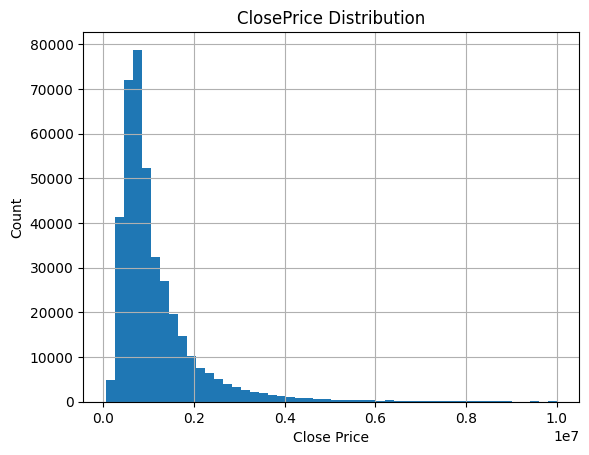

count    3.976080e+05
mean     1.148515e+06
std      9.676588e+05
min      5.000000e+04
25%      5.999990e+05
50%      8.500000e+05
75%      1.350000e+06
max      1.000000e+07
Name: ClosePrice, dtype: float64
float64
2      250000.0
7      413700.0
12     725000.0
25     600000.0
27    1810000.0
28     920000.0
30    1400000.0
31    1675000.0
34     510000.0
35    4700000.0
Name: ClosePrice, dtype: float64


In [4]:
#target variable: Closeprice

df['ClosePrice'].hist(bins=50)
plt.title('ClosePrice Distribution')
plt.xlabel('Close Price')
plt.ylabel('Count')
plt.show()

print(df['ClosePrice'].describe())


print(df['ClosePrice'].dtype)
print(df['ClosePrice'].head(10))

In [5]:
#exploration
print(df['ClosePrice'].isnull().sum())
print(df['ClosePrice'].count())
print(df['PropertyType'].value_counts())
print(df['PropertySubType'].value_counts())
print(selected_files)
print(df['PropertyType'].value_counts())
print(df['PropertySubType'].value_counts())
print(df[df['ClosePrice'] < 10000]['ClosePrice'].count())
print(df[df['ClosePrice'] > 10000000]['ClosePrice'].count())


print([col for col in df.columns if 'Bedroom' in col])
print([col for col in df.columns if 'Bathroom' in col])
print([col for col in df.columns if 'Living' in col])
print([col for col in df.columns if 'Lot' in col])
print([col for col in df.columns if 'Close' in col])

0
397608
PropertyType
Residential    397608
Name: count, dtype: int64
PropertySubType
SingleFamilyResidence    397608
Name: count, dtype: int64
<generator object <genexpr> at 0x116391d80>
PropertyType
Residential    397608
Name: count, dtype: int64
PropertySubType
SingleFamilyResidence    397608
Name: count, dtype: int64
0
0
['BedroomsTotal', 'MainLevelBedrooms']
['BathroomsTotalInteger']
['LivingArea']
['LotSizeAcres', 'LotSizeDimensions', 'LotSizeArea', 'LotSizeSquareFeet']
['CloseDate', 'ClosePrice']


In [6]:
#determine outlier 

Q1 = df['ClosePrice'].quantile(0.25)
Q3 = df['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")
print(f"Outliers below: {(df['ClosePrice'] < lower_bound).sum()}")
print(f"Outliers above: {(df['ClosePrice'] > upper_bound).sum()}")

print(df[df['ClosePrice'] < 50000])   # likely data errors
print(df[df['ClosePrice'] > 20000000]) # likely data errors

# Look at the distribution of the outliers
print(df[df['ClosePrice'] > 2497500]['ClosePrice'].describe())

# Where are these expensive properties located?
print(df[df['ClosePrice'] > 2497500]['City'].value_counts().head(20))

#Right skewed, so not realistic extremes

Lower bound: $-525,002
Upper bound: $2,475,002
Outliers below: 0
Outliers above: 29658
Empty DataFrame
Columns: [Flooring, ViewYN, WaterfrontYN, BasementYN, PoolPrivateYN, OriginalListPrice, ListingKey, ListAgentEmail, CloseDate, ClosePrice, ListAgentFirstName, ListAgentLastName, Latitude, Longitude, UnparsedAddress, PropertyType, LivingArea, ListPrice, DaysOnMarket, ListOfficeName, BuyerOfficeName, CoListOfficeName, ListAgentFullName, CoListAgentFirstName, CoListAgentLastName, BuyerAgentMlsId, BuyerAgentFirstName, BuyerAgentLastName, FireplacesTotal, AssociationFeeFrequency, AboveGradeFinishedArea, ListingKeyNumeric, MLSAreaMajor, TaxAnnualAmount, CountyOrParish, MlsStatus, ElementarySchool, AttachedGarageYN, ParkingTotal, BuilderName, PropertySubType, LotSizeAcres, SubdivisionName, BuyerOfficeAOR, YearBuilt, BuyerAgencyCompensationType, StreetNumberNumeric, ListingId, BathroomsTotalInteger, City, BuyerAgencyCompensation, TaxYear, BuildingAreaTotal, BedroomsTotal, ContractStatusChange

(367405, 82)
         ClosePrice    LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  3.976080e+05  3.973780e+05  397608.000000          397482.000000   
mean   1.148515e+06  2.005458e+03       3.456716               2.589423   
std    9.676588e+05  3.990244e+03       0.939432               7.456135   
min    5.000000e+04  0.000000e+00       0.000000               0.000000   
25%    5.999990e+05  1.360000e+03       3.000000               2.000000   
50%    8.500000e+05  1.782000e+03       3.000000               2.000000   
75%    1.350000e+06  2.394000e+03       4.000000               3.000000   
max    1.000000e+07  2.308680e+06      35.000000            2980.000000   

       LotSizeSquareFeet  
count       3.905960e+05  
mean        1.714003e+05  
std         1.087870e+07  
min         0.000000e+00  
25%         5.684000e+03  
50%         7.258000e+03  
75%         1.024800e+04  
max         1.987207e+09  


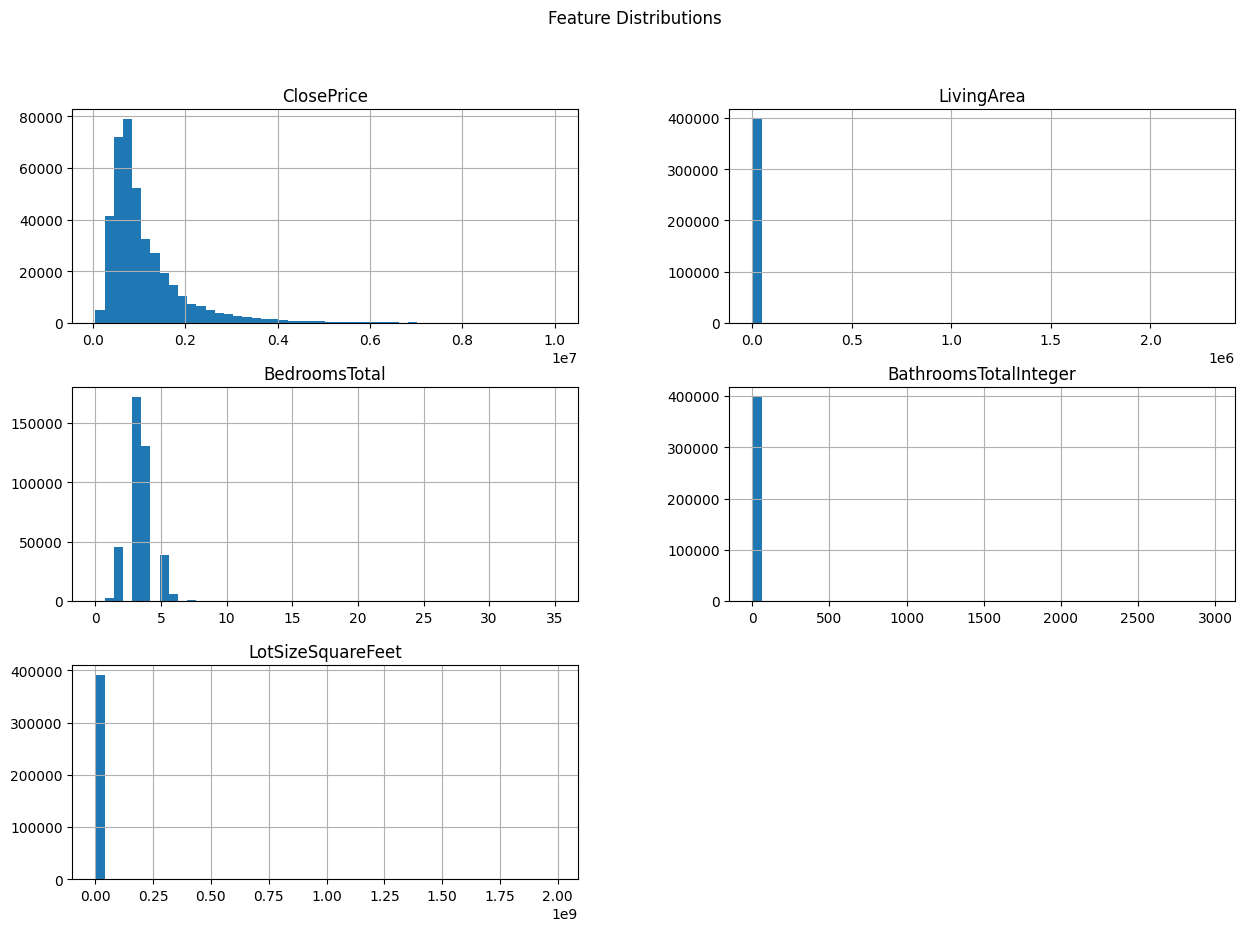

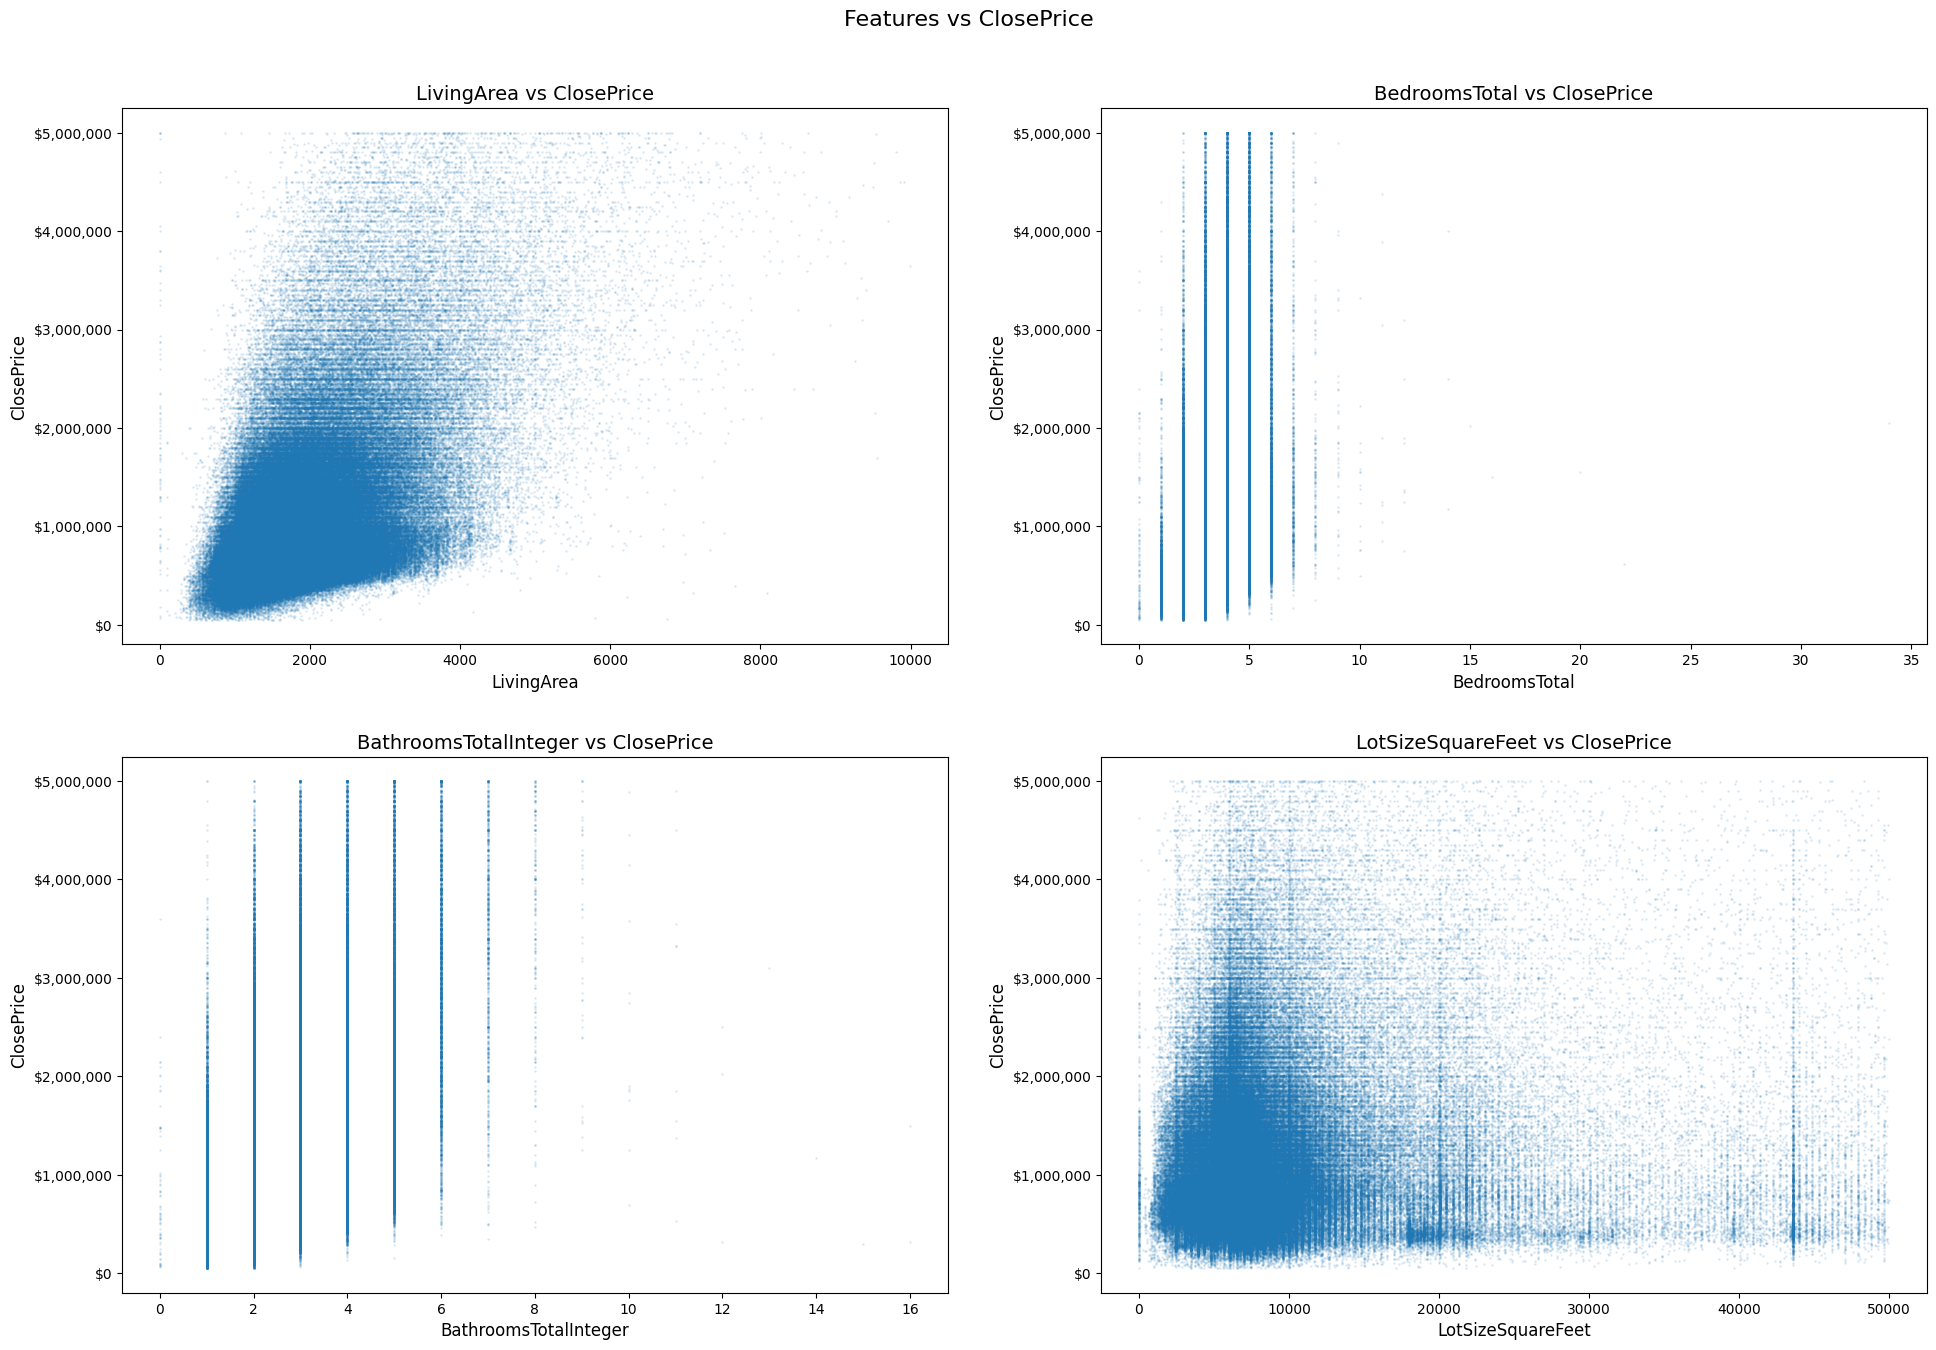

In [8]:
# Remove the noticable outlier for cleaner plots
df_clean = df[
    (df['LivingArea'] < 10000) &
    (df['BathroomsTotalInteger'] < 20) &
    (df['LotSizeSquareFeet'] < 50000) &
    (df['ClosePrice'] >= 50000) &
    (df['ClosePrice'] <= 5000000)
]
print(df_clean.shape)

#explore key features relation

cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']

print(df[cols].describe())

# Plot all distributions/ individual plots
df[cols].hist(bins=50, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.show()

# scatter plots to visualize relationships
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].scatter(df_clean[col], df_clean['ClosePrice'], alpha=0.1, s=1)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('ClosePrice', fontsize=12)
    axes[i].set_title(f'{col} vs ClosePrice', fontsize=14)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Features vs ClosePrice', fontsize=16)
plt.tight_layout(pad=3.0)
plt.show()